# 02 — Sales Trends & Forecasting
Weekly revenue modeling with **SARIMA**, backtested with a 3-week holdout, plus a growth decomposition (volume vs. ticket size).

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
PINK, DARK, GREY = "#e75480", "#2d2d2d", "#999999"
RAW, PROC = "../data/raw/", "../data/processed/"
orders = pd.read_csv(PROC + "orders_clean.csv", parse_dates=["created_at", "order_date", "order_month"])
valid = orders[(~orders.cancelled) & (orders.total > 500)].copy()
daily = pd.read_csv(RAW + "daily_sales.csv", parse_dates=["day"])
fmt_pkr = mtick.FuncFormatter(lambda x, _: f"{x/1000:,.0f}K")

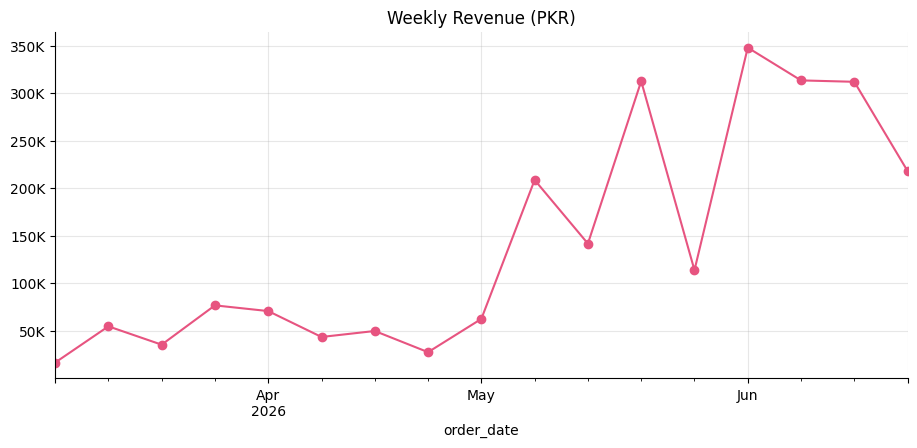

17 full weeks | mean weekly revenue last 4 wks: 297,857 PKR


In [2]:
# Weekly revenue series (trim partial current week)
wk = valid.set_index("order_date").resample("W-SUN").total.sum()
wk = wk[wk.index < wk.index[-1]]  # drop partial final week
ax = wk.plot(marker="o", color=PINK, title="Weekly Revenue (PKR)")
ax.yaxis.set_major_formatter(fmt_pkr); plt.show()
print(f"{len(wk)} full weeks | mean weekly revenue last 4 wks: {wk[-4:].mean():,.0f} PKR")

Backtest MAPE (3-wk holdout): 33.6%


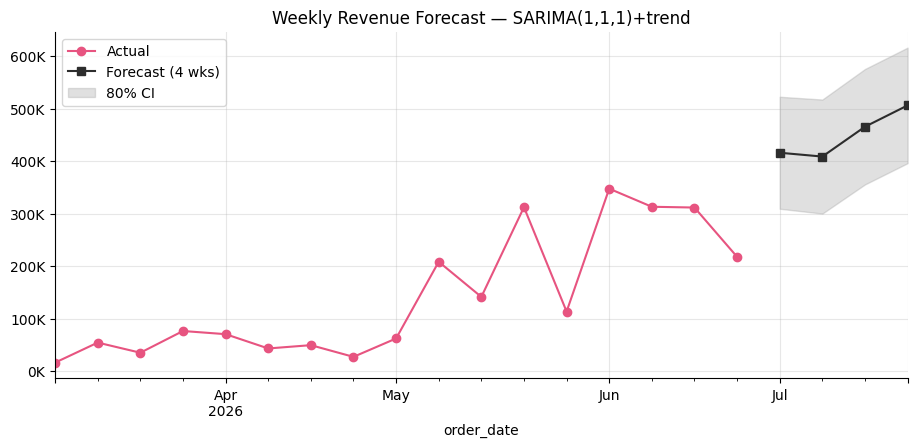

,forecast_pkr
2026-07-05,416320.0
2026-07-12,409047.0
2026-07-19,465865.0
2026-07-26,506467.0


In [3]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
train, test = wk[:-3], wk[-3:]
model = SARIMAX(train, order=(1,1,1), trend="t").fit(disp=False)
pred = model.forecast(3)
mape = (abs(pred.values - test.values) / test.values).mean()
print(f"Backtest MAPE (3-wk holdout): {mape:.1%}")

final = SARIMAX(wk, order=(1,1,1), trend="t").fit(disp=False)
fc = final.get_forecast(4); ci = fc.conf_int(alpha=.2)
ax = wk.plot(marker="o", color=PINK, label="Actual")
fc.predicted_mean.plot(ax=ax, marker="s", color=DARK, label="Forecast (4 wks)")
ax.fill_between(ci.index, ci.iloc[:,0].clip(0), ci.iloc[:,1], color=GREY, alpha=.3, label="80% CI")
ax.yaxis.set_major_formatter(fmt_pkr); ax.legend(); ax.set_title("Weekly Revenue Forecast — SARIMA(1,1,1)+trend")
plt.show(); fc.predicted_mean.round(0).to_frame("forecast_pkr")

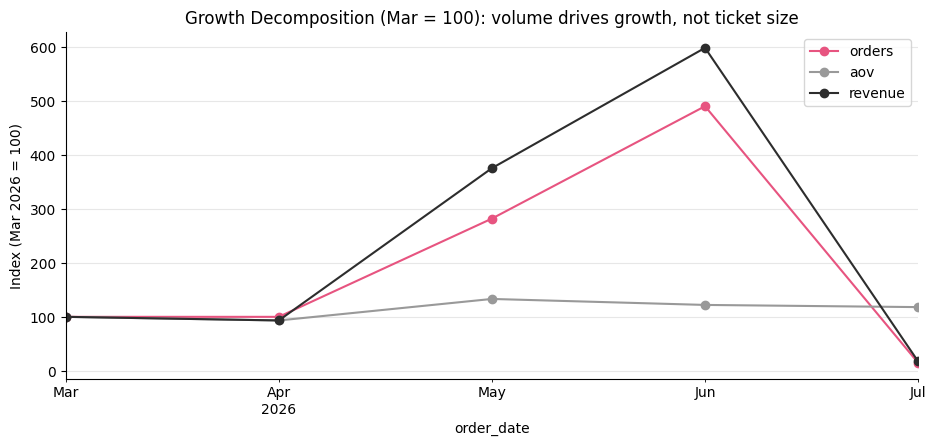

,revenue,orders,aov
order_date,,,
2026-03-01,213743.0,61,3504.0
2026-04-01,199406.0,61,3269.0
2026-05-01,802432.0,172,4665.0
2026-06-01,1278797.0,299,4277.0
2026-07-01,37218.0,9,4135.0


In [4]:
# Growth decomposition: is growth from more orders or bigger baskets?
m = valid.set_index("order_date").resample("MS").agg(revenue=("total","sum"), orders=("order","count"))
m["aov"] = m.revenue / m.orders
idx = m.loc["2026-03":].copy(); idx = idx / idx.iloc[0] * 100
ax = idx[["orders","aov","revenue"]].plot(marker="o", color=[PINK, GREY, DARK],
    title="Growth Decomposition (Mar = 100): volume drives growth, not ticket size")
ax.set_ylabel("Index (Mar 2026 = 100)"); plt.show()
m.round(0)

### Findings
- The SARIMA model (with linear trend) projects **PKR 410–505K/week** over the next 4 weeks — it extrapolates June's climb. The 3-week backtest MAPE of **33.6%** says treat this as directional, not precise: 17 weeks of history is short and the May 21 wholesale-style spike adds noise.
- A conservative planning number is the trailing 4-week average (~**PKR 298K/week** ≈ PKR 1.2–1.3M/month), with the model's upper path achievable only if June's social reach is sustained.
- Growth decomposition: revenue growth is **volume-driven** (orders 61 → 299, +390%) while AOV is roughly flat around PKR 3.3–4.7K. Levers to lift AOV: bundles, free-shipping thresholds, checkout upsells.
- Re-run the forecast monthly; each additional month of data will materially tighten the intervals.